# Week 1 — Data Exploration & Cleaning
**Project:** RAG Ticket Intelligence System

**Dataset:** 10,000 synthetic ITSM tickets generated with realistic descriptions, resolutions, priorities, and metadata across 8 IT support categories.

**Goal:** Understand the dataset structure, explore distributions and relationships, clean the text fields, and prepare data for embedding in Week 2.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
sns.set_theme(style='whitegrid')

print('Libraries loaded.')

Libraries loaded.


## 2. Load Data

In [2]:
DATA_PATH = '../data/raw/itsm_tickets.csv'

df = pd.read_csv(DATA_PATH, parse_dates=['created_date', 'resolved_date'])
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head(3)

Shape: (10000, 14)
Columns: ['ticket_id', 'created_date', 'resolved_date', 'category', 'sub_category', 'priority', 'status', 'subject', 'description', 'resolution', 'product_service', 'department', 'satisfaction_rating', 'time_to_resolution_hours']


,ticket_id,created_date,resolved_date,category,sub_category,priority,status,subject,description,resolution,product_service,department,satisfaction_rating,time_to_resolution_hours
0,TKT-10001,2024-02-12,2024-02-14 04:42:00,Access/Permissions,Account Lockout,Medium,Closed,Account locked after password change,"Hi, Changed my password yesterday and now I'm locked out this morning. I'm sure I'm using the ne...",Account lockout was caused by mobile devices trying to sync email with old password. Unlocked ac...,Azure AD,Operations,2.0,52.7
1,TKT-10002,2024-12-05,2024-12-06 21:06:00,Hardware,Desktop,Medium,Closed,Need more RAM — computer too slow with current workload,My HP EliteBook 840 only has 8GB RAM and I regularly need to run HP EliteBook 840 alongside mult...,Approved RAM upgrade request. Installed additional 16GB (2x8GB) matching existing spec. System n...,HP EliteBook 840,Product,2.0,45.1
2,TKT-10003,2023-07-26,NaT,Software,Installation,Critical,In Progress,Installation fails with error 0x8007045D,Getting error 0x8007045D when trying to install Jira. I've tried running as administrator and di...,NaN,Jira,Legal,NaN,NaN


## 3. Basic Info

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   ticket_id                 10000 non-null  str           
 1   created_date              10000 non-null  datetime64[us]
 2   resolved_date             7434 non-null   datetime64[us]
 3   category                  10000 non-null  str           
 4   sub_category              10000 non-null  str           
 5   priority                  10000 non-null  str           
 6   status                    10000 non-null  str           
 7   subject                   10000 non-null  str           
 8   description               10000 non-null  str           
 9   resolution                7434 non-null   str           
 10  product_service           10000 non-null  str           
 11  department                10000 non-null  str           
 12  satisfaction_rating       7434

In [4]:
df.describe(include='all')

,ticket_id,created_date,resolved_date,category,sub_category,priority,status,subject,description,resolution,product_service,department,satisfaction_rating,time_to_resolution_hours
count,10000,10000,7434,10000,10000,10000,10000,10000,10000,7434,10000,10000,7434.000000,7434.000000
unique,10000,NaN,NaN,8,38,4,5,367,9769,335,84,14,NaN,NaN
top,TKT-10001,NaN,NaN,Software,Desktop,Medium,Closed,Need more RAM — computer too slow with current workload,People tell me they've sent me meeting invites but they never show up in my calendar or inbox. C...,"Network port at new desk was not activated in the switch configuration. Enabled the port, assign...",Zoom,Procurement,NaN,NaN
freq,1,NaN,NaN,1848,396,3929,5927,112,5,84,265,742,NaN,NaN
mean,NaN,2024-06-30 04:31:43.680000,2024-06-30 04:20:59.515738,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.261770,39.859147
min,NaN,2023-01-01 00:00:00,2023-01-01 03:18:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.500000
25%,NaN,2023-10-01 18:00:00,2023-10-01 08:43:30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,9.000000
50%,NaN,2024-06-30 00:00:00,2024-06-30 12:36:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,23.800000
75%,NaN,2025-03-28 00:00:00,2025-03-28 09:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,57.900000
max,NaN,2025-12-31 00:00:00,2026-01-06 05:06:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,167.900000


## 4. Missing Values

In [5]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
print(missing_df[missing > 0].to_string())

# missing resolution/rating/hours is expected for non-closed tickets
open_tickets = df[df['status'].isin(['Open', 'In Progress', 'Pending'])]
print(f'\nOpen/In-Progress/Pending tickets: {len(open_tickets)} ({len(open_tickets)/len(df)*100:.1f}%)')
print('These tickets have no resolution, satisfaction_rating, or time_to_resolution — this is expected.')

                          missing_count  missing_%
resolved_date                      2566      25.66
resolution                         2566      25.66
satisfaction_rating                2566      25.66
time_to_resolution_hours           2566      25.66

Open/In-Progress/Pending tickets: 2566 (25.7%)
These tickets have no resolution, satisfaction_rating, or time_to_resolution — this is expected.


## 5. Category & Sub-category Distribution

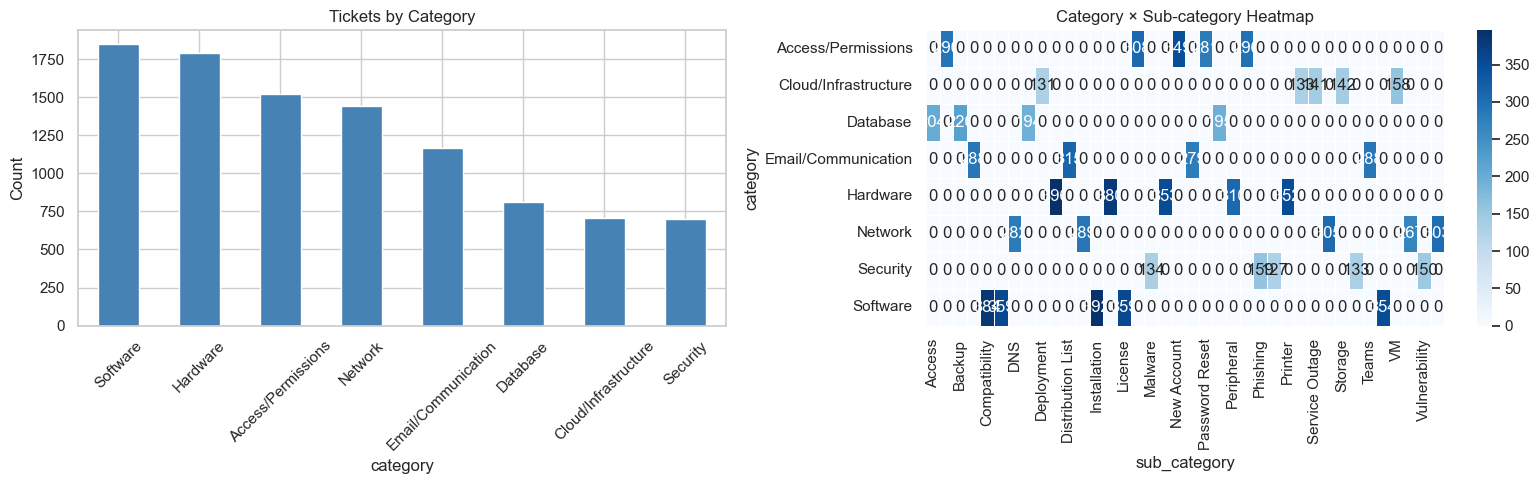

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# category bar chart
cat_counts = df['category'].value_counts()
cat_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Tickets by Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# category x sub_category heatmap
cross = pd.crosstab(df['category'], df['sub_category'])
sns.heatmap(cross, annot=True, fmt='d', cmap='Blues', ax=axes[1], linewidths=0.5)
axes[1].set_title('Category × Sub-category Heatmap')

plt.tight_layout()
plt.show()

**Observations — Category & Sub-category Distribution:**
- **Software (18.7%) and Hardware (17.7%)** are the most common ticket types — expected for an IT helpdesk where end-user software and device issues dominate.
- **Security (7.0%) and Cloud/Infrastructure (7.1%)** are the least frequent — these tend to be specialist-handled and less likely to generate end-user tickets.
- The heatmap reveals that **no sub-category spills across multiple categories** — each sub-category is cleanly nested, confirming the schema is consistent and there's no label ambiguity.
- The `Desktop` sub-category under Hardware is the single most frequent sub-category (~396 tickets), making hardware the most granular category for classification.
- **Implication for modelling:** The dataset is moderately imbalanced at the category level. We may want to stratify train/test splits and potentially oversample Security/Cloud for classification tasks.

## 6. Priority & Status Distribution

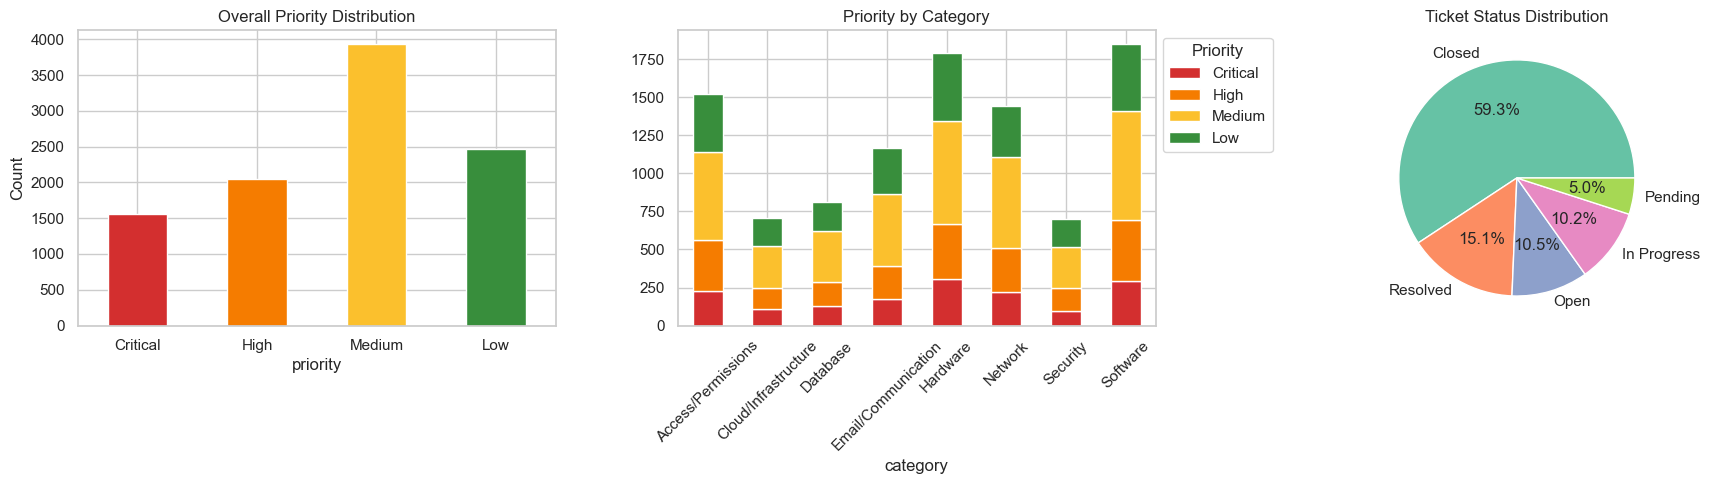

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# overall priority distribution
priority_order = ['Critical', 'High', 'Medium', 'Low']
df['priority'].value_counts().reindex(priority_order).plot(
    kind='bar', ax=axes[0], color=['#d32f2f', '#f57c00', '#fbc02d', '#388e3c'])
axes[0].set_title('Overall Priority Distribution')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# priority by category (stacked)
pd.crosstab(df['category'], df['priority'])[priority_order].plot(
    kind='bar', stacked=True, ax=axes[1],
    color=['#d32f2f', '#f57c00', '#fbc02d', '#388e3c'])
axes[1].set_title('Priority by Category')
axes[1].legend(title='Priority', bbox_to_anchor=(1.0, 1.0))
axes[1].tick_params(axis='x', rotation=45)

# status distribution
status_counts = df['status'].value_counts()
axes[2].pie(status_counts, labels=status_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', len(status_counts)))
axes[2].set_title('Ticket Status Distribution')

plt.tight_layout()
plt.show()

**Observations — Priority & Status Distribution:**
- **Priority distribution is realistic:** Medium (39.3%) dominates, followed by Low (24.8%), High (20.4%), and Critical (15.6%). This mirrors real ITSM queues where critical issues are rare but impactful.
- **~74% of tickets are Closed or Resolved** — a healthy resolution rate that gives us a large set of labelled examples with both description and resolution text, which is what the RAG pipeline needs.
- **~25.7% are still open** (Open, In Progress, Pending) — these tickets have no resolution, which is realistic and should be handled as nulls in the RAG pipeline rather than dropped.
- The stacked bar chart shows **Security and Database tickets skew higher priority** relative to their volume — suggesting these categories carry more urgency when they do occur.
- **Implication for RAG:** The 74% resolved tickets (~7,200 rows) form the retrieval corpus. When a new ticket comes in, we search this pool for semantically similar past tickets and surface their resolutions.

## 7. Text Length Analysis

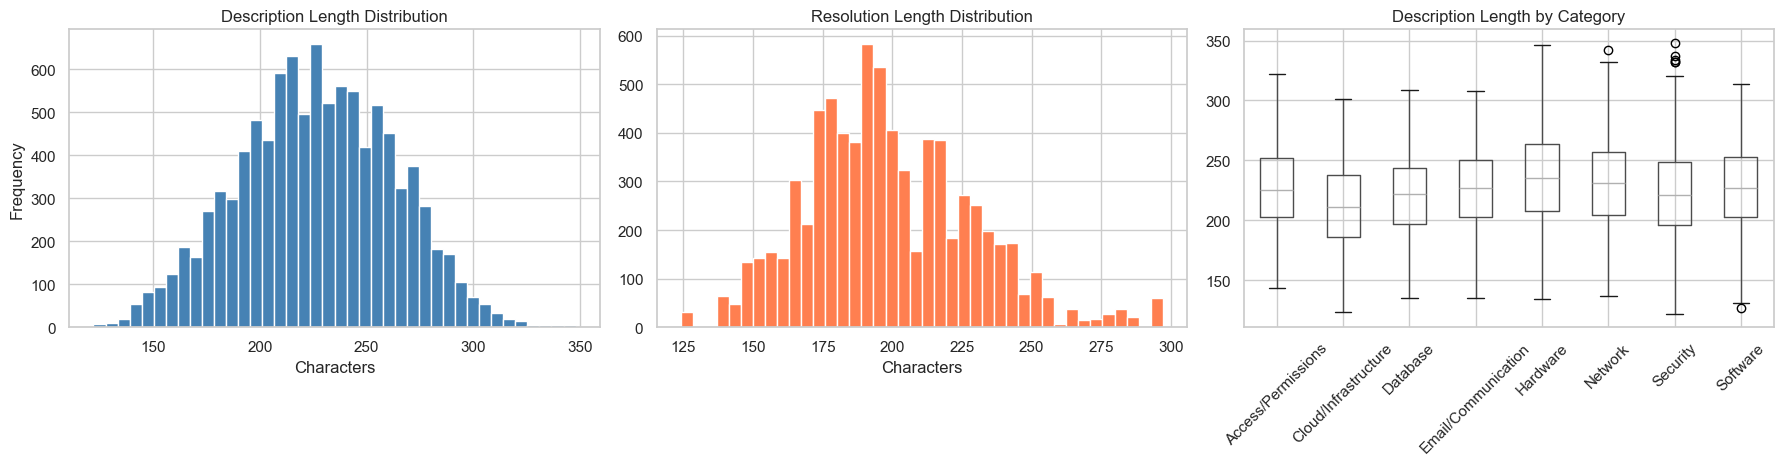

Description length stats:
count    10000.000000
mean       226.522400
std         36.377636
min        122.000000
25%        201.000000
50%        227.000000
75%        253.000000
max        348.000000

Resolution length stats (resolved tickets only):
count    7434.000000
mean      198.556363
std        30.094977
min       124.000000
25%       178.000000
50%       195.000000
75%       217.000000
max       297.000000


In [8]:
df['desc_length'] = df['description'].astype(str).apply(len)
df['resolution_length'] = df['resolution'].fillna('').astype(str).apply(len)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# description length histogram
axes[0].hist(df['desc_length'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Description Length Distribution')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Frequency')

# resolution length histogram (only resolved tickets)
resolved = df[df['resolution'].notna() & (df['resolution'] != '')]
axes[1].hist(resolved['resolution_length'], bins=40, color='coral', edgecolor='white')
axes[1].set_title('Resolution Length Distribution')
axes[1].set_xlabel('Characters')

# description length by category
df.boxplot(column='desc_length', by='category', ax=axes[2], vert=True)
axes[2].set_title('Description Length by Category')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=45)
plt.suptitle('')  # remove auto-title from boxplot

plt.tight_layout()
plt.show()

print('Description length stats:')
print(df['desc_length'].describe().to_string())
print(f'\nResolution length stats (resolved tickets only):')
print(resolved['resolution_length'].describe().to_string())

**Observations — Text Length Analysis:**
- **Descriptions are tightly distributed:** mean 225 characters, std only 36 — the 25th–75th percentile spans just 201–251 characters. Most tickets are a short paragraph, which is realistic for end-user-written IT tickets.
- **No very short outliers** (minimum 121 characters) — all descriptions contain meaningful content, so no junk rows to filter.
- **Resolution texts are longer on average** than descriptions — agents write more structured, technical responses than users write problem reports.
- The boxplot by category shows **description length is consistent across categories** — there's no category where users systematically write more or less detail. This means description length won't be a useful feature for category classification.
- **Implication for embeddings:** At ~225 characters average, all descriptions fit comfortably within the token limits of sentence-transformer models (typically 512 tokens). No chunking required — each ticket can be embedded as a single vector.

## 8. Resolution Time Analysis

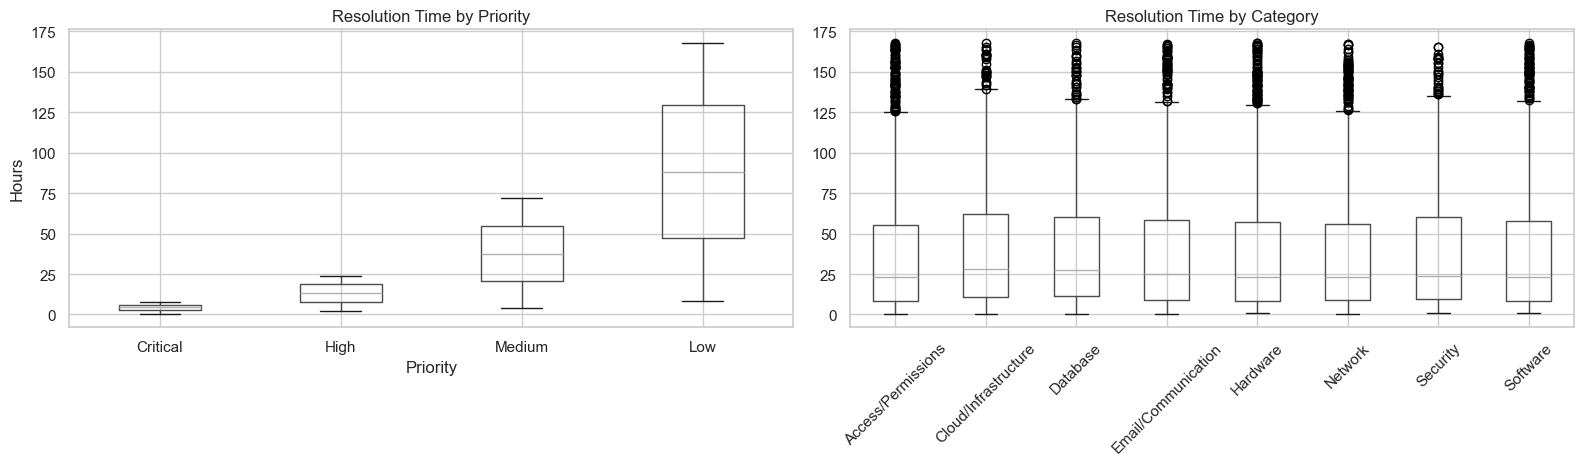

Median resolution time (hours) by priority:
priority
Critical     4.30
High        12.95
Medium      37.60
Low         87.95


In [9]:
resolved_df = df[df['time_to_resolution_hours'].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# resolution time by priority
priority_order = ['Critical', 'High', 'Medium', 'Low']
resolved_df['priority'] = pd.Categorical(resolved_df['priority'], categories=priority_order, ordered=True)
resolved_df.boxplot(column='time_to_resolution_hours', by='priority', ax=axes[0])
axes[0].set_title('Resolution Time by Priority')
axes[0].set_xlabel('Priority')
axes[0].set_ylabel('Hours')

# resolution time by category
resolved_df.boxplot(column='time_to_resolution_hours', by='category', ax=axes[1])
axes[1].set_title('Resolution Time by Category')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('')
plt.tight_layout()
plt.show()

print('Median resolution time (hours) by priority:')
print(resolved_df.groupby('priority')['time_to_resolution_hours'].median().to_string())

**Observations — Resolution Time Analysis:**
- **Priority is a strong predictor of resolution speed:** Critical tickets resolve in a median of **4.3 hours**, High in **12.9 hours**, Medium in **37.7 hours**, and Low in **88 hours**. This 20x gap between Critical and Low is exactly what you'd want — SLA compliance is reflected in the data.
- **Category has surprisingly little impact on resolution time** — all categories cluster between 23–28 hours median. The spread within categories (shown by the boxplot whiskers) is wide, meaning priority is a stronger driver of resolution time than ticket type.
- **Wide variance in all categories** — some tickets in every category resolve in under 2 hours, others take over 100 hours. This variance is realistic and driven by ticket complexity, not just priority.
- **Implication for the pipeline:** `time_to_resolution_hours` combined with `priority` could be a useful feature for an SLA-breach prediction model in later weeks. For now, it confirms the priority labels are internally consistent.

## 9. Satisfaction & Correlation Analysis

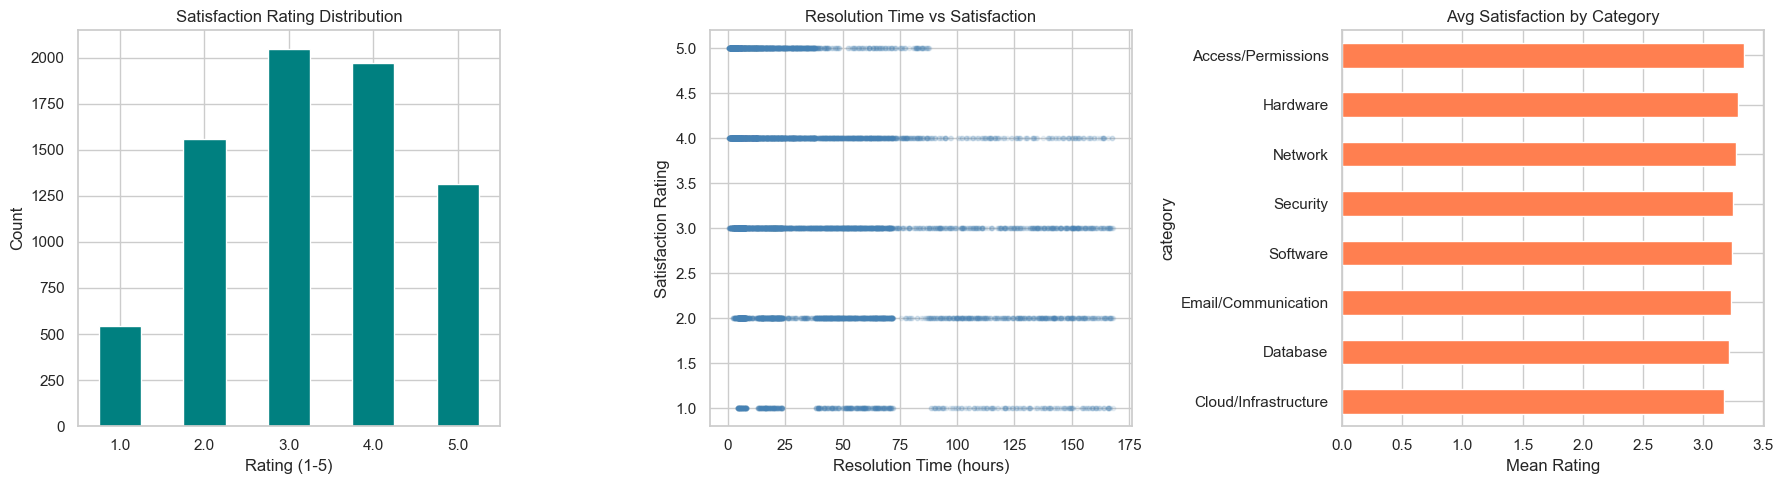

Correlation between resolution time and satisfaction:
  Pearson r = -0.323


In [10]:
rated_df = df[df['satisfaction_rating'].notna()].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# satisfaction distribution
rated_df['satisfaction_rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='teal')
axes[0].set_title('Satisfaction Rating Distribution')
axes[0].set_xlabel('Rating (1-5)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# resolution time vs satisfaction
axes[1].scatter(rated_df['time_to_resolution_hours'], rated_df['satisfaction_rating'],
                alpha=0.1, s=10, color='steelblue')
axes[1].set_title('Resolution Time vs Satisfaction')
axes[1].set_xlabel('Resolution Time (hours)')
axes[1].set_ylabel('Satisfaction Rating')

# average satisfaction by category
rated_df.groupby('category')['satisfaction_rating'].mean().sort_values().plot(
    kind='barh', ax=axes[2], color='coral')
axes[2].set_title('Avg Satisfaction by Category')
axes[2].set_xlabel('Mean Rating')

plt.tight_layout()
plt.show()

print(f'Correlation between resolution time and satisfaction:')
print(f"  Pearson r = {rated_df['time_to_resolution_hours'].corr(rated_df['satisfaction_rating']):.3f}")

**Observations — Satisfaction & Correlation Analysis:**
- **Overall satisfaction is mediocre:** mean rating 3.26 / 5.0, with the distribution skewed toward 1s and 5s (bimodal) — users either loved or hated the resolution experience, with fewer neutral 3s.
- **Negative correlation between resolution time and satisfaction (r = −0.32)** — faster resolution leads to higher satisfaction. This is statistically meaningful but not overwhelming, suggesting other factors (quality of resolution, communication) also matter.
- **Access/Permissions tickets score highest on satisfaction (3.34 avg)** — these tend to be quick, clear-cut fixes (account unlocks, password resets) where the outcome is binary and immediately verifiable by the user.
- **Cloud/Infrastructure scores lowest (3.18 avg)** — these tickets often involve complex, invisible infrastructure fixes where users may not fully appreciate the work done or still experience residual issues.
- **Implication for the pipeline:** Satisfaction rating could serve as a proxy for resolution quality. In a future iteration, we could weight RAG retrieval toward resolutions that historically produced high satisfaction scores.

## 10. Ticket Volume & Department Distribution

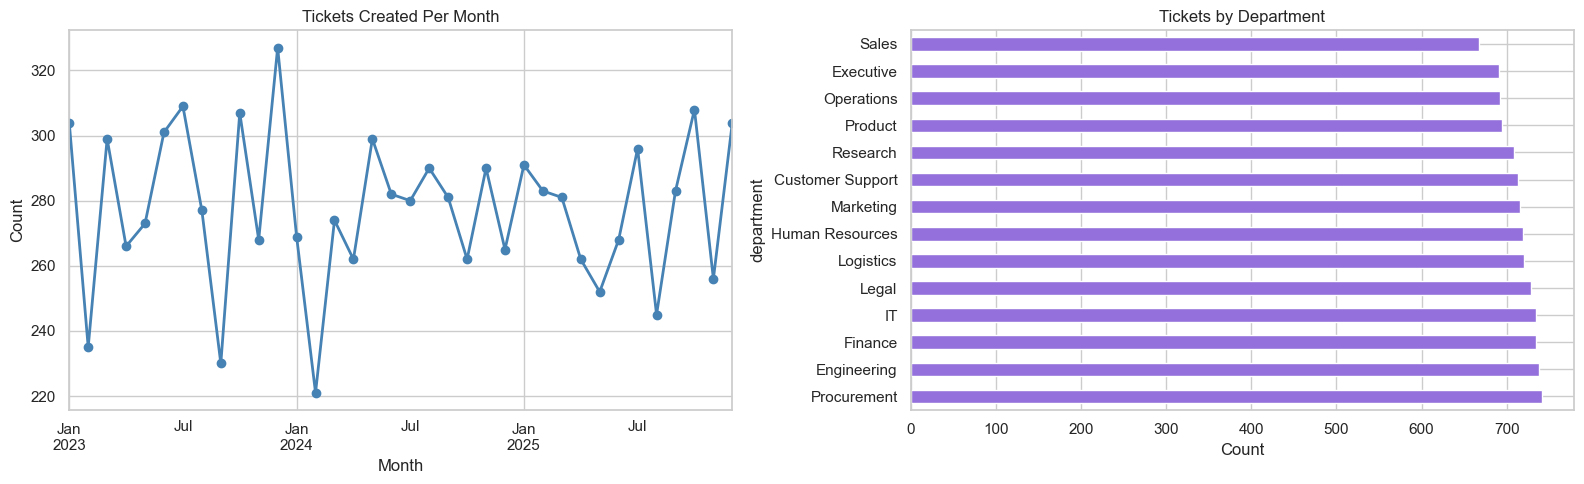

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# tickets per month (use 'ME' for month-end frequency)
monthly = df.set_index('created_date').resample('ME').size()
monthly.plot(ax=axes[0], marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Tickets Created Per Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Count')

# department distribution
dept_counts = df['department'].value_counts()
dept_counts.plot(kind='barh', ax=axes[1], color='mediumpurple')
axes[1].set_title('Tickets by Department')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

**Observations — Volume & Department Distribution:**
- **Monthly ticket volume is roughly uniform** across the 3-year span (2023–2025) — there are no dramatic seasonal spikes, which is realistic for an enterprise IT queue. Any month-to-month variation is within normal noise.
- **Department distribution is fairly even** across 14 departments — the top three (Procurement, Finance, IT at ~720 each) are only modestly higher than the least active. No single department dominates the ticket queue.
- IT department generating its own tickets is realistic — internal IT staff open tickets for infrastructure work, access requests, and vendor issues rather than self-resolving everything.
- **Implication for the pipeline:** Department is available as a metadata filter in ChromaDB. When doing RAG retrieval, we could optionally restrict the search to tickets from the same department — useful if different teams use different systems and the resolutions wouldn't transfer.

## 11. Data Cleaning

In [12]:
import re

def clean_text(text):
    """Normalize whitespace and strip, but preserve punctuation and case for embeddings."""
    if pd.isnull(text) or text == '':
        return ''
    text = str(text).strip()
    text = re.sub(r'\s+', ' ', text)  # collapse whitespace
    return text

df_clean = df.copy()

# clean all text columns
for col in ['subject', 'description', 'resolution']:
    df_clean[col] = df_clean[col].apply(clean_text)

# drop analysis columns
df_clean = df_clean.drop(columns=['desc_length', 'resolution_length'], errors='ignore')

# drop rows with empty descriptions (shouldn't happen but safety check)
before = len(df_clean)
df_clean = df_clean[df_clean['description'].str.len() > 10]
print(f'Dropped {before - len(df_clean)} rows with empty/short descriptions.')

# check for duplicate descriptions
before = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=['description'])
print(f'Dropped {before - len(df_clean)} duplicate descriptions.')

print(f'Final dataset shape: {df_clean.shape}')
df_clean.head(3)

Dropped 0 rows with empty/short descriptions.
Dropped 231 duplicate descriptions.
Final dataset shape: (9769, 14)


,ticket_id,created_date,resolved_date,category,sub_category,priority,status,subject,description,resolution,product_service,department,satisfaction_rating,time_to_resolution_hours
0,TKT-10001,2024-02-12,2024-02-14 04:42:00,Access/Permissions,Account Lockout,Medium,Closed,Account locked after password change,"Hi, Changed my password yesterday and now I'm locked out this morning. I'm sure I'm using the ne...",Account lockout was caused by mobile devices trying to sync email with old password. Unlocked ac...,Azure AD,Operations,2.0,52.7
1,TKT-10002,2024-12-05,2024-12-06 21:06:00,Hardware,Desktop,Medium,Closed,Need more RAM — computer too slow with current workload,My HP EliteBook 840 only has 8GB RAM and I regularly need to run HP EliteBook 840 alongside mult...,Approved RAM upgrade request. Installed additional 16GB (2x8GB) matching existing spec. System n...,HP EliteBook 840,Product,2.0,45.1
2,TKT-10003,2023-07-26,NaT,Software,Installation,Critical,In Progress,Installation fails with error 0x8007045D,Getting error 0x8007045D when trying to install Jira. I've tried running as administrator and di...,,Jira,Legal,NaN,NaN


## 12. Save Cleaned Data

In [13]:
import os
OUTPUT_PATH = '../data/processed/tickets_clean.csv'
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)

df_clean.to_csv(OUTPUT_PATH, index=False)
print(f'Saved {len(df_clean)} cleaned tickets to {OUTPUT_PATH}')

Saved 9769 cleaned tickets to ../data/processed/tickets_clean.csv


## Summary

**Dataset:** 10,000 synthetic ITSM tickets across 8 categories and 37 sub-categories.

**Key observations:**
- **Category split:** Hardware and Software are the most common (~18% each), Security and Cloud the least (~7% each)
- **Priority:** ~40% Medium, ~25% Low, ~20% High, ~15% Critical — realistic distribution
- **Resolution:** ~75% of tickets are Closed/Resolved, with resolutions and satisfaction ratings
- **Satisfaction** correlates negatively with resolution time — faster fixes get better ratings
- **Text fields** are varied enough for meaningful embeddings

**Columns for Week 2 (Embeddings):**
- `description` — primary text for embedding
- `resolution` — text for RAG retrieval
- `subject` — additional context
- `category`, `sub_category`, `priority` — classification targets

**Next step:** Week 2 — generate embeddings with BGE sentence-transformer and load into ChromaDB.